# Lecture: PixelCNN as an Autoregressive Model

In the previous lecture, we modeled data using a Gaussian distribution and learned how to estimate its parameters from observations. While this works well in low dimensions, modeling high-dimensional data such as images quickly becomes difficult. A 28×28 image already has 784 dimensions, and directly modeling the full joint distribution would require an impractically large number of parameters.

To address this, we use the **chain rule of probability**. For images, this means we model each pixel conditioned on all previously generated pixels. This idea leads to **PixelCNN**, introduced in van den Oord et al., *PixelCNN* (2016).

PixelCNN is an autoregressive neural network that enforces this factorization using masked convolutions. During training, the model learns to predict the probability distribution of each pixel given the earlier pixels. Since it provides explicit probabilities, we can train it by maximizing the exact log-likelihood. Image generation then proceeds sequentially: pixel by pixel, from top-left to bottom-right. PixelCNN illustrates a powerful principle: instead of modeling correlations explicitly with large covariance matrices, we model them implicitly through conditional prediction.

Run the following cell only if you are working with google colab to copy the required .py file in the root directory. If you are working locally just ignore this cell!

In [ ]:
!git clone https://github.com/Fjoelsak/AIBIP.git
!cp AIBIP/06-Generative_Image_Models/PixelCNN.py ./

### Data Preparation for PixelCNN Training

In this section, we prepare the MNIST dataset for training the PixelCNN model.

Since PixelCNN models a discrete probability distribution over pixel values, we convert the grayscale images into 32 discrete intensity levels (0–31). Each pixel is therefore treated as a categorical variable. To speed up training while keeping sufficient data diversity, we use a subset of 15,000 training images. The data is loaded in mini-batches and moved to GPU memory if available.

In [6]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# -------------------------------------------------
# Device configuration
# -------------------------------------------------
# Use GPU if available, otherwise fall back to CPU.
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -------------------------------------------------
# 1) Dataset preparation
# -------------------------------------------------

# PixelCNN models discrete pixel values.
# MNIST images are originally in the range [0, 1].
# We convert them into 32 discrete intensity levels (0–31).
transform = transforms.Compose([
    transforms.ToTensor(),          # Convert PIL image to tensor in [0, 1]
    lambda x: (x * 31).long()       # Quantize to 32 discrete levels
])

# Load MNIST training dataset
dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Use only a subset of the dataset to reduce training time
subset = Subset(dataset, range(15000))

# Create data loader for mini-batch training
loader = DataLoader(
    subset,
    batch_size=256,     # Larger batch size improves GPU utilization
    shuffle=True,       # Shuffle data each epoch
    num_workers=0,      # Parallel data loading
    pin_memory=True     # Faster transfer to GPU
)

Device: cpu


### Training the PixelCNN Model

In this section, we instantiate the PixelCNN model and train it using maximum likelihood estimation.

Since PixelCNN models a categorical distribution over discrete pixel values, we use the cross-entropy loss, which corresponds to the negative log-likelihood of the data. During training, the model learns to predict the distribution of each pixel conditioned on all previously observed pixels. The parameters are optimized using the Adam optimizer.

In [8]:
import torch.optim as optim
import torch.nn.functional as F

from PixelCNN import FastPixelCNN

# -------------------------------------------------
# Model initialization
# -------------------------------------------------

# Instantiate the PixelCNN model and move it to the selected device
model = FastPixelCNN().to(device)

# Optional performance improvement for PyTorch 2.x
# torch.compile can provide runtime speedups through graph optimization
if hasattr(torch, "compile"):
    model = torch.compile(model, backend="eager")

# Use Adam optimizer for parameter updates
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -------------------------------------------------
# Training loop
# -------------------------------------------------

epochs = 10  # Number of training epochs

for epoch in range(epochs):
    model.train()  # Set model to training mode
    total_loss = 0

    for x, _ in loader:
        # Move input batch to device (GPU if available)
        # non_blocking=True allows faster transfers when using pinned memory
        x = x.to(device, non_blocking=True)

        # Reset gradients from previous iteration
        optimizer.zero_grad()

        # Forward pass: predict logits for each pixel value
        logits = model(x)

        # Cross-entropy loss corresponds to negative log-likelihood
        # Targets must have shape (batch_size, height, width)
        loss = F.cross_entropy(logits, x.squeeze(1))

        # Backpropagation
        loss.backward()

        # Parameter update
        optimizer.step()

        total_loss += loss.item()

    # Print average loss per epoch
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

C:\GitHub\AIBIP\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1, Loss: 1.3818
Epoch 2, Loss: 0.6511
Epoch 3, Loss: 0.5164
Epoch 4, Loss: 0.4809
Epoch 5, Loss: 0.4501
Epoch 6, Loss: 0.4375
Epoch 7, Loss: 0.4458
Epoch 8, Loss: 0.4287
Epoch 9, Loss: 0.4273
Epoch 10, Loss: 0.4247


In [9]:
model.save_model()

Model saved to deep_pixelcnn_mnist.pth.


If you do not want to train, you can load the model with the parameters (32 greyscale steps, 15,000 training images, 256 batch size, 128 hidden_dims, 6 num_layers, 10 epochs)

In [ ]:
model.load_model(path="AIBIP/06-Generative_Image_Models/models/deep_pixelcnn_mnist.pth", device='cpu')

### Autoregressive Image Generation

After training, we can generate new images by sampling from the learned PixelCNN model.

Since PixelCNN factorizes the joint distribution into a product of conditional distributions, image generation proceeds sequentially. Pixels are generated one at a time in raster-scan order (row by row, left to right). For each pixel, the model predicts a categorical probability distribution over possible intensity values. We sample from this distribution and insert the sampled value into the image before moving to the next pixel. This sequential process guarantees that each pixel is conditioned on all previously generated pixels.

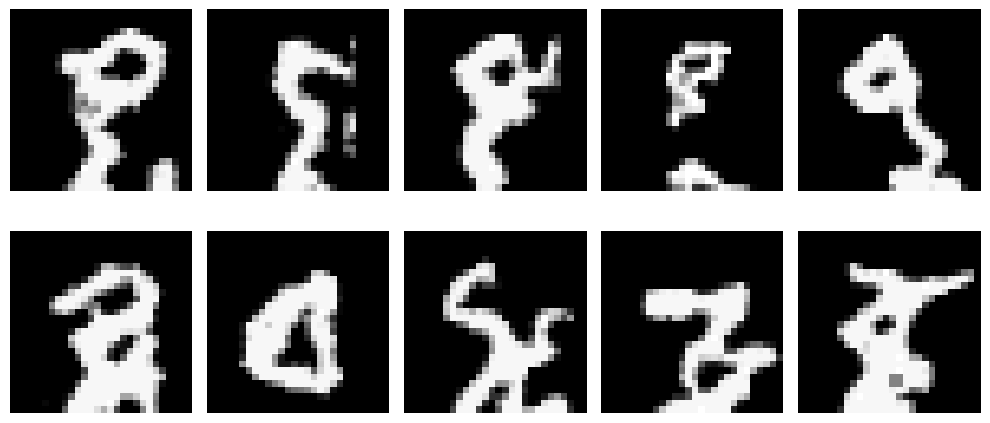

In [10]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -------------------------------------------------
# Sampling (autoregressive generation)
# -------------------------------------------------

def sample(model):
    """
    Generate a single image from the trained PixelCNN model.

    The image is generated pixel by pixel in raster-scan order.
    At each position, the model predicts a categorical distribution
    over pixel intensities, from which we sample.

    Args:
        model (nn.Module):
            Trained PixelCNN model.

    Returns:
        torch.Tensor:
            Generated image of shape (28, 28) with values in [0, 1].
    """
    model.eval()  # Set model to evaluation mode

    # Start with an empty image (all zeros)
    x = torch.zeros(1, 1, 28, 28).long().to(device)

    # Disable gradient computation during sampling
    with torch.no_grad():

        # Raster-scan order: row by row, left to right
        for i in range(28):
            for j in range(28):

                # Forward pass to obtain logits for all pixels
                logits = model(x)

                # Extract logits for the current pixel (i, j)
                probs = F.softmax(logits[:, :, i, j], dim=1)

                # Sample a discrete pixel value from the categorical distribution
                x[:, :, i, j] = torch.multinomial(probs, 1)

    # Convert discrete values (0–31) back to [0, 1] range for visualization
    return x.squeeze().cpu().float() / 31.0


# -------------------------------------------------
# Generate and visualize multiple samples
# -------------------------------------------------

plt.figure(figsize=(10, 5))

for i in range(10):
    img = sample(model)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()